In [72]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import plotly.express as px
import numpy as np

In [73]:
# Tentar ler o arquivo CSV com uma codificação que evite o erro de decodificação
try:
    df = pd.read_csv('acidentes2019_todas_causas_tipos_novo.csv', sep = ";", encoding='ISO-8859-1')
except UnicodeDecodeError as e:
    print(f"Erro ao ler o arquivo: {e}")
    exit(1)

# Mostrar os nomes das colunas para verificar se 'COD_TARIF' está correto
print("Nomes das colunas:", df.columns.tolist())

# Mostrar a quantidade de linhas atuais
linhas_atuais = len(df)
print(f"Quantidade de linhas atuais: {linhas_atuais}")

C:\Users\PR837UK\AppData\Local\Temp\ipykernel_11772\1517322775.py:3: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('acidentes2019_todas_causas_tipos_novo.csv', sep = ";", encoding='ISO-8859-1')


Nomes das colunas: ['id', 'pesid', 'data_inversa', 'uf', 'causa_principal', 'causa_acidente', 'tipo_acidente', 'id_veiculo', 'tipo_veiculo', 'marca', 'ano_fabricacao_veiculo', 'tipo_envolvido', 'idade', 'sexo']
Quantidade de linhas atuais: 324192


In [74]:
df.head()

,id,pesid,data_inversa,uf,causa_principal,causa_acidente,tipo_acidente,id_veiculo,tipo_veiculo,marca,ano_fabricacao_veiculo,tipo_envolvido,idade,sexo
0,182210,402102.0,01/01/2019,SP,Sim,Falta de Atenção à Condução,Colisão com objeto estático,324888.0,Automóvel,PEUGEOT/206 SW 16PRESENC/206 SW 16PRESENC,2005.0,Condutor,27.0,Masculino
1,182210,402106.0,01/01/2019,SP,Sim,Falta de Atenção à Condução,Colisão com objeto estático,324888.0,Automóvel,PEUGEOT/206 SW 16PRESENC/206 SW 16PRESENC,2005.0,Passageiro,18.0,Masculino
2,182210,402104.0,01/01/2019,SP,Sim,Falta de Atenção à Condução,Colisão com objeto estático,324888.0,Automóvel,PEUGEOT/206 SW 16PRESENC/206 SW 16PRESENC,2005.0,Passageiro,34.0,Feminino
3,182210,402103.0,01/01/2019,SP,Sim,Falta de Atenção à Condução,Colisão com objeto estático,324888.0,Automóvel,PEUGEOT/206 SW 16PRESENC/206 SW 16PRESENC,2005.0,Passageiro,34.0,Masculino
4,182211,402126.0,01/01/2019,PR,Sim,Falta de Atenção à Condução,Colisão traseira,324868.0,Motoneta,HONDA/C100 BIZ ES/C100 BIZ ES,2004.0,Condutor,42.0,Masculino


In [75]:
df.tail()

,id,pesid,data_inversa,uf,causa_principal,causa_acidente,tipo_acidente,id_veiculo,tipo_veiculo,marca,ano_fabricacao_veiculo,tipo_envolvido,idade,sexo
324187,619251,NaN,16/10/2019,MG,Sim,Falta de Atenção à Condução,Colisão lateral,1109414.0,Semireboque,SR/RODOVALE GOLD 3E/RODOVALE GOLD 3E,2017.0,NaN,NaN,NaN
324188,619251,1385627.0,16/10/2019,MG,Sim,Falta de Atenção à Condução,Colisão lateral,1109413.0,Automóvel,FIAT/PALIO WK ADVEN FLEX/PALIO WK ADVEN FLEX,2012.0,Condutor,37.0,Masculino
324189,619251,1385626.0,16/10/2019,MG,Sim,Falta de Atenção à Condução,Colisão lateral,1109413.0,Automóvel,FIAT/PALIO WK ADVEN FLEX/PALIO WK ADVEN FLEX,2012.0,Passageiro,44.0,Feminino
324190,619251,1385625.0,16/10/2019,MG,Sim,Falta de Atenção à Condução,Colisão lateral,1109412.0,Caminhão-trator,VOLVO/FH 460 6X2T/FH 460 6X2T,2015.0,Condutor,27.0,Masculino
324191,619251,1385624.0,16/10/2019,MG,Sim,Falta de Atenção à Condução,Colisão lateral,NaN,NaN,NA/NA/NA,NaN,Testemunha,NaN,Não Informado


In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 324192 entries, 0 to 324191
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      324192 non-null  object 
 1   pesid                   297403 non-null  float64
 2   data_inversa            324192 non-null  object 
 3   uf                      324192 non-null  object 
 4   causa_principal         324192 non-null  object 
 5   causa_acidente          324192 non-null  object 
 6   tipo_acidente           324152 non-null  object 
 7   id_veiculo              311821 non-null  float64
 8   tipo_veiculo            311821 non-null  object 
 9   marca                   324192 non-null  object 
 10  ano_fabricacao_veiculo  311821 non-null  float64
 11  tipo_envolvido          297403 non-null  object 
 12  idade                   268395 non-null  float64
 13  sexo                    297403 non-null  object 
dtypes: float64(4), objec

In [77]:
# Converte as colunas para inteiro, mantendo valores nulos como NaN
df["idade"] = (
    pd.to_numeric(df["idade"], errors="coerce")  # converte para número, NaN se inválido
    .astype("Int64")                              # tipo inteiro que aceita NaN
)

df["ano_fabricacao_veiculo"] = (
    pd.to_numeric(df["ano_fabricacao_veiculo"], errors="coerce")
    .astype("Int64")                              # tipo inteiro que aceita NaN
)

# Exibe algumas linhas para conferir
print(df[["idade", "ano_fabricacao_veiculo"]].head())
print("\nTipos das colunas:")
print(df[["idade", "ano_fabricacao_veiculo"]].dtypes)

   idade  ano_fabricacao_veiculo
0     27                    2005
1     18                    2005
2     34                    2005
3     34                    2005
4     42                    2004

Tipos das colunas:
idade                     Int64
ano_fabricacao_veiculo    Int64
dtype: object


**Remoção de linhas duplicadas, que a coluna CAUSA_PRINCIPAL seja igual a NÃO e a coluna TIPO_ENVOLVIDO seja diferente de "condutor"**

In [78]:
# =========================
# 1) Normalização
# =========================
df["id"] = df["id"].astype(str)
df["causa_principal_norm"] = df["causa_principal"].astype(str).str.strip().str.lower()
df["tipo_envolvido_norm"]  = df["tipo_envolvido"].astype(str).str.strip().str.lower()

total_inicial = len(df)

# =========================
# 2) IDs únicos (apenas uma ocorrência)
# =========================
vc = df["id"].value_counts()
ids_unicos = vc[vc == 1].index

df_id_unico = df[df["id"].isin(ids_unicos)]
excluidos_por_id_duplicado = total_inicial - len(df_id_unico)

# =========================
# 3) Filtro causa_principal = "sim"
# =========================
df_causa = df_id_unico[df_id_unico["causa_principal_norm"] == "sim"]
excluidos_por_causa = len(df_id_unico) - len(df_causa)

# =========================
# 4) Filtro tipo_envolvido = "condutor"
# =========================
df_filtrado = df_causa[df_causa["tipo_envolvido_norm"] == "condutor"] \
                .drop(columns=["causa_principal_norm", "tipo_envolvido_norm"])

excluidos_por_tipo = len(df_causa) - len(df_filtrado)

# =========================
# 5) Resumo dos números
# =========================
itens_achados = len(df_filtrado)            # linhas que passaram por todos os filtros
itens_excluidos = total_inicial - itens_achados
numero_atual = itens_achados                # igual ao final

print("=== Resumo ===")
print(f"Total inicial de linhas: {total_inicial:,}".replace(",", "."))
print(f"IDs únicos (contagem de IDs com 1 ocorrência): {len(ids_unicos):,}".replace(",", "."))
print(f"Linhas após manter só IDs únicos: {len(df_id_unico):,}".replace(",", "."))
print(f"  - Excluídas por ID duplicado: {excluidos_por_id_duplicado:,}".replace(",", "."))

print(f"Linhas após filtrar causa_principal='sim': {len(df_causa):,}".replace(",", "."))
print(f"  - Excluídas por causa_principal != 'sim': {excluidos_por_causa:,}".replace(",", "."))

print(f"Linhas após filtrar tipo_envolvido='condutor': {len(df_filtrado):,}".replace(",", "."))
print(f"  - Excluídas por tipo_envolvido != 'condutor': {excluidos_por_tipo:,}".replace(",", "."))

print("=== Totais finais ===")
print(f"Itens achados (resultado final): {itens_achados:,}".replace(",", "."))
print(f"Itens excluídos (total): {itens_excluidos:,}".replace(",", "."))
print(f"Número atual (linhas restantes): {numero_atual:,}".replace(",", "."))

# Visualizar algumas linhas do resultado
df = df_filtrado
df.head()

=== Resumo ===
Total inicial de linhas: 324.192
IDs únicos (contagem de IDs com 1 ocorrência): 9.468
Linhas após manter só IDs únicos: 9.468
  - Excluídas por ID duplicado: 314.724
Linhas após filtrar causa_principal='sim': 9.468
  - Excluídas por causa_principal != 'sim': 0
Linhas após filtrar tipo_envolvido='condutor': 9.468
  - Excluídas por tipo_envolvido != 'condutor': 0
=== Totais finais ===
Itens achados (resultado final): 9.468
Itens excluídos (total): 314.724
Número atual (linhas restantes): 9.468


,id,pesid,data_inversa,uf,causa_principal,causa_acidente,tipo_acidente,id_veiculo,tipo_veiculo,marca,ano_fabricacao_veiculo,tipo_envolvido,idade,sexo
4,182211,402126.0,01/01/2019,PR,Sim,Falta de Atenção à Condução,Colisão traseira,324868.0,Motoneta,HONDA/C100 BIZ ES/C100 BIZ ES,2004,Condutor,42,Masculino
5,182212,402092.0,01/01/2019,SC,Sim,Animais na Pista,Colisão com objeto estático,324863.0,Automóvel,RENAULT/SANDERO EXP1016V/SANDERO EXP1016V,2009,Condutor,47,Feminino
6,182214,402095.0,01/01/2019,CE,Sim,Ingestão de Substâncias Psicoativas,Colisão com objeto estático,324878.0,Automóvel,TOYOTA/ETIOS HB XS/ETIOS HB XS,2013,Condutor,<NA>,Feminino
9,182216,403879.0,01/01/2019,SC,Sim,Ingestão de Substâncias Psicoativas,Saída de leito carroçável,324875.0,Automóvel,I/CHEVROLET AGILE LT/CHEVROLET AGILE LT,2011,Condutor,26,Masculino
44,182228,403997.0,01/01/2019,MG,Sim,Velocidade Incompatível,Colisão com objeto estático,324881.0,Automóvel,GM/CORSA HATCH MAXX/CORSA HATCH MAXX,2006,Condutor,22,Masculino


**Criação de coluna REGIÃO**

In [62]:
# Dicionário UF → Região
uf_para_regiao = {
    # Sudeste
    "SP": "Sudeste", "RJ": "Sudeste", "MG": "Sudeste", "ES": "Sudeste",
    # Sul
    "PR": "Sul", "SC": "Sul", "RS": "Sul",
    # Centro-Oeste
    "DF": "Centro-Oeste", "GO": "Centro-Oeste", "MT": "Centro-Oeste", "MS": "Centro-Oeste",
    # Norte
    "AC": "Norte", "AP": "Norte", "AM": "Norte", "PA": "Norte", "RO": "Norte", "RR": "Norte", "TO": "Norte",
    # Nordeste
    "AL": "Nordeste", "BA": "Nordeste", "CE": "Nordeste", "MA": "Nordeste", "PB": "Nordeste",
    "PE": "Nordeste", "PI": "Nordeste", "RN": "Nordeste", "SE": "Nordeste",
}

# --- Limpeza/normalização da coluna UF ---
df["uf"] = (
    df["uf"]
    .astype(str)
    .str.strip()
    .str.upper()
)

# Cria a coluna REGIAO mapeando a UF
df["regiao"] = df["uf"].map(uf_para_regiao)

# (opcional) marcar UFs desconhecidas
df.loc[df["regiao"].isna() & df["uf"].notna(), "regiao"] = "Desconhecida"

# Visualização de checagem
print(df[["uf", "regiao"]].head())

    uf    regiao
4   PR       Sul
5   SC       Sul
6   CE  Nordeste
9   SC       Sul
44  MG   Sudeste


In [63]:
df.head(10)

,id,pesid,data_inversa,uf,causa_principal,causa_acidente,tipo_acidente,id_veiculo,tipo_veiculo,marca,ano_fabricacao_veiculo,tipo_envolvido,idade,sexo,regiao
4,182211,402126.0,01/01/2019,PR,Sim,Falta de Atenção à Condução,Colisão traseira,324868.0,Motoneta,HONDA/C100 BIZ ES/C100 BIZ ES,2004,Condutor,42,Masculino,Sul
5,182212,402092.0,01/01/2019,SC,Sim,Animais na Pista,Colisão com objeto estático,324863.0,Automóvel,RENAULT/SANDERO EXP1016V/SANDERO EXP1016V,2009,Condutor,47,Feminino,Sul
6,182214,402095.0,01/01/2019,CE,Sim,Ingestão de Substâncias Psicoativas,Colisão com objeto estático,324878.0,Automóvel,TOYOTA/ETIOS HB XS/ETIOS HB XS,2013,Condutor,<NA>,Feminino,Nordeste
9,182216,403879.0,01/01/2019,SC,Sim,Ingestão de Substâncias Psicoativas,Saída de leito carroçável,324875.0,Automóvel,I/CHEVROLET AGILE LT/CHEVROLET AGILE LT,2011,Condutor,26,Masculino,Sul
44,182228,403997.0,01/01/2019,MG,Sim,Velocidade Incompatível,Colisão com objeto estático,324881.0,Automóvel,GM/CORSA HATCH MAXX/CORSA HATCH MAXX,2006,Condutor,22,Masculino,Sudeste
122,182256,403856.0,01/01/2019,CE,Sim,Animais na Pista,Atropelamento de Animal,324937.0,Caminhão,I/MB 15SPRINT RONTAN AMB/MB 15SPRINT RONTAN AMB,2012,Condutor,35,Masculino,Nordeste
145,182263,402859.0,01/01/2019,MT,Sim,Defeito Mecânico no Veículo,Incêndio,324940.0,Caminhão,FORD/CARGO 815 N/CARGO 815 N,2011,Condutor,30,Masculino,Centro-Oeste
146,182265,402196.0,01/01/2019,PR,Sim,Falta de Atenção à Condução,Saída de leito carroçável,324942.0,Automóvel,VW/GOL CL/GOL CL,1993,Condutor,47,Masculino,Sul
147,182268,402200.0,01/01/2019,MG,Sim,Pista Escorregadia,Capotamento,324943.0,Automóvel,FIAT/PALIO FIRE ECONOMY/PALIO FIRE ECONOMY,2013,Condutor,28,Masculino,Sudeste
178,182274,402208.0,01/01/2019,RJ,Sim,Ingestão de Álcool,Colisão com objeto estático,324949.0,Automóvel,GM/CELTA 4P LIFE/CELTA 4P LIFE,2007,Condutor,29,Masculino,Sudeste


**Verificação de tipos de veículos na coluna TIPO_VEICULO**

In [64]:
# Lista de valores únicos na coluna tipo_veiculo
valores_unicos = df["tipo_veiculo"].dropna().unique()

# Exibe os valores únicos e a contagem
print("Itens únicos na coluna 'tipo_veiculo':")
for i, v in enumerate(valores_unicos, start=1):
    print(f"{i}. {v}")

print(f"\nTotal de itens únicos: {len(valores_unicos)}")

Itens únicos na coluna 'tipo_veiculo':
1. Motoneta
2. Automóvel
3. Caminhão
4. Caminhonete
5. Motocicleta
6. Caminhão-trator
7. Bicicleta
8. Ônibus
9. Utilitário
10. Camioneta
11. Micro-ônibus
12. Ciclomotor
13. Outros
14. Semireboque
15. Trator de rodas
16. Reboque

Total de itens únicos: 16


**Remoção de veículos como caminhões e ônibus**

In [65]:
# Lista de tipos de veículos permitidos
tipos_permitidos = [
    "Automóvel",
    "Motoneta",
    "Caminhonete",
    "Camioneta",
    "Motocicleta",
    "Utilitário",
    "Outros"
]

# Filtra apenas linhas com tipo_veiculo dentro da lista
df_filtrado = df[df["tipo_veiculo"].isin(tipos_permitidos)]

# Exibe resumo
print(f"Total inicial: {len(df):,}".replace(",", "."))
print(f"Total após filtro: {len(df_filtrado):,}".replace(",", "."))
print(f"Linhas removidas: {len(df) - len(df_filtrado):,}".replace(",", "."))

# Visualiza as primeiras linhas do resultado
df = df_filtrado
df.head()

Total inicial: 9.468
Total após filtro: 8.264
Linhas removidas: 1.204


,id,pesid,data_inversa,uf,causa_principal,causa_acidente,tipo_acidente,id_veiculo,tipo_veiculo,marca,ano_fabricacao_veiculo,tipo_envolvido,idade,sexo,regiao
4,182211,402126.0,01/01/2019,PR,Sim,Falta de Atenção à Condução,Colisão traseira,324868.0,Motoneta,HONDA/C100 BIZ ES/C100 BIZ ES,2004,Condutor,42,Masculino,Sul
5,182212,402092.0,01/01/2019,SC,Sim,Animais na Pista,Colisão com objeto estático,324863.0,Automóvel,RENAULT/SANDERO EXP1016V/SANDERO EXP1016V,2009,Condutor,47,Feminino,Sul
6,182214,402095.0,01/01/2019,CE,Sim,Ingestão de Substâncias Psicoativas,Colisão com objeto estático,324878.0,Automóvel,TOYOTA/ETIOS HB XS/ETIOS HB XS,2013,Condutor,<NA>,Feminino,Nordeste
9,182216,403879.0,01/01/2019,SC,Sim,Ingestão de Substâncias Psicoativas,Saída de leito carroçável,324875.0,Automóvel,I/CHEVROLET AGILE LT/CHEVROLET AGILE LT,2011,Condutor,26,Masculino,Sul
44,182228,403997.0,01/01/2019,MG,Sim,Velocidade Incompatível,Colisão com objeto estático,324881.0,Automóvel,GM/CORSA HATCH MAXX/CORSA HATCH MAXX,2006,Condutor,22,Masculino,Sudeste


**Check se há itens duplicados na coluna ID**

In [66]:
# Conta quantas vezes cada ID aparece
contagem_ids = df["id"].value_counts()

# Filtra apenas IDs que aparecem mais de uma vez (duplicados)
ids_duplicados = contagem_ids[contagem_ids > 1]

# Quantidade de IDs duplicados
qtd_ids_duplicados = len(ids_duplicados)

# Quantidade total de linhas duplicadas (somando todas as ocorrências extras)
qtd_linhas_duplicadas = ids_duplicados.sum() - qtd_ids_duplicados

print(f"Quantidade de IDs duplicados (valores únicos): {qtd_ids_duplicados}")
print(f"Quantidade total de linhas duplicadas: {qtd_linhas_duplicadas}")

# Exibe os IDs duplicados e suas contagens
print("\nIDs duplicados e suas contagens:")
print(ids_duplicados)

Quantidade de IDs duplicados (valores únicos): 0
Quantidade total de linhas duplicadas: 0

IDs duplicados e suas contagens:
Series([], Name: count, dtype: int64)


**Contagem por sexo e número de "ignorados"**

In [67]:
# Copia do DataFrame original
df = df.copy()

# Total de linhas da base original
total_linhas = len(df)

# Contagem de NaN
qtd_nan = df["sexo"].isna().sum()

# Contagem de valores "Ignorado" e "Não informado" (independente de maiúsculas/minúsculas)
qtd_ignorado = df["sexo"].str.strip().str.lower().eq("ignorado").sum()
qtd_nao_informado = df["sexo"].str.strip().str.lower().eq("não informado").sum()

# Remove valores indesejados: NaN, "Ignorado", "Não informado"
df_sexo = df["sexo"].dropna()
df_sexo = df_sexo[~df_sexo.str.strip().str.lower().isin(["ignorado", "não informado"])]

# Contagem de valores válidos
contagem_sexo = df_sexo.value_counts()

# Valores únicos válidos
valores_unicos = contagem_sexo.index.tolist()

# Exibe os resultados
print("=== Contagem por valor na coluna 'sexo' (ignorando NaN, 'Ignorado' e 'Não informado') ===")
print(contagem_sexo)

print("\n=== Resumo ===")
print(f"Total de linhas na base: {total_linhas}")
print(f"Valores nulos (NaN): {qtd_nan}")
print(f"Valores 'Ignorado': {qtd_ignorado}")
print(f"Valores 'Não informado': {qtd_nao_informado}")
print(f"Total de registros válidos considerados: {len(df_sexo)}")

print("\nValores únicos válidos na coluna 'sexo':")
for i, v in enumerate(valores_unicos, start=1):
    print(f"{i}. {v}")

=== Contagem por valor na coluna 'sexo' (ignorando NaN, 'Ignorado' e 'Não informado') ===
sexo
Masculino    6537
Feminino     1096
Name: count, dtype: int64

=== Resumo ===
Total de linhas na base: 8264
Valores nulos (NaN): 0
Valores 'Ignorado': 63
Valores 'Não informado': 568
Total de registros válidos considerados: 7633

Valores únicos válidos na coluna 'sexo':
1. Masculino
2. Feminino


In [68]:

# Copia do DataFrame original
df = df.copy()

# Normalização básica e remoção de nulos
df["regiao"] = df["regiao"].astype(str).str.strip()
df["causa_acidente"] = df["causa_acidente"].astype(str).str.strip()

df_valid = df[
    df["regiao"].notna() &
    df["regiao"].ne("") &
    df["causa_acidente"].notna() &
    df["causa_acidente"].ne("")
]

# Contagem por região x causa
contagem = (
    df_valid.groupby(["regiao", "causa_acidente"])
            .size()
            .reset_index(name="qtd")
)

# Rank dentro de cada região
contagem["rank_regiao"] = contagem.groupby("regiao")["qtd"].rank(method="first", ascending=False)

# Top 5 por região
top5_por_regiao = (
    contagem[contagem["rank_regiao"] <= 5]
    .sort_values(["regiao", "qtd"], ascending=[True, False])
    .reset_index(drop=True)
)

print("=== Top 5 causas por região ===")
print(top5_por_regiao)


=== Top 5 causas por região ===
          regiao               causa_acidente   qtd  rank_regiao
0   Centro-Oeste  Falta de Atenção à Condução   331          1.0
1   Centro-Oeste           Ingestão de Álcool   129          2.0
2   Centro-Oeste  Defeito Mecânico no Veículo    94          3.0
3   Centro-Oeste            Condutor Dormindo    65          4.0
4   Centro-Oeste      Velocidade Incompatível    56          5.0
5       Nordeste  Falta de Atenção à Condução   415          1.0
6       Nordeste             Animais na Pista   229          2.0
7       Nordeste           Ingestão de Álcool   154          3.0
8       Nordeste  Defeito Mecânico no Veículo   139          4.0
9       Nordeste           Pista Escorregadia   102          5.0
10         Norte  Falta de Atenção à Condução   118          1.0
11         Norte           Ingestão de Álcool    44          2.0
12         Norte               Defeito na Via    35          3.0
13         Norte             Animais na Pista    27       

C:\Users\PR837UK\AppData\Local\Temp\ipykernel_11772\526477550.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


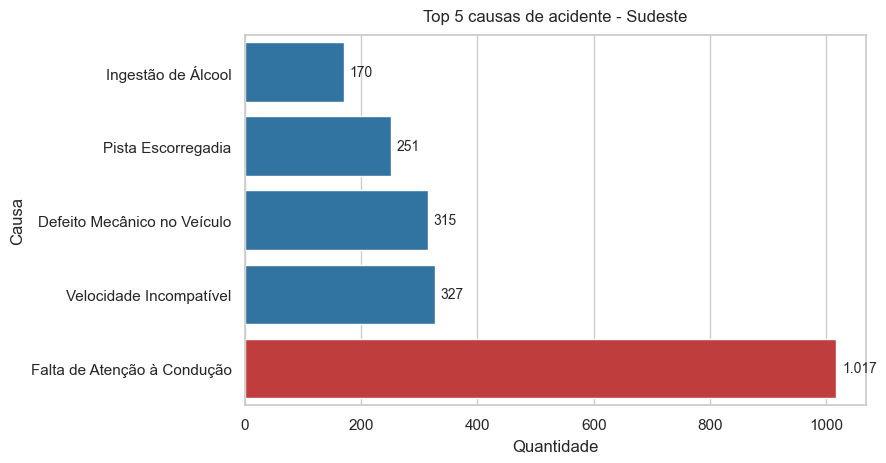

In [69]:
reg = "Sudeste"
top_reg = top5_por_regiao[top5_por_regiao["regiao"] == reg].sort_values("qtd", ascending=True)

# Se não houver dados para a região, evita erro
if top_reg.empty:
    print(f"Sem dados para a região: {reg}")
else:
    sns.set_theme(style="whitegrid")

    # Paleta: todas azuis e a maior (última, pois ascending=True) em vermelho
    n = len(top_reg)
    colors = ["#1f77b4"] * n
    colors[-1] = "#d62728"  # vermelho para a maior

    plt.figure(figsize=(9, 4.8))
    ax = sns.barplot(
        data=top_reg,
        y="causa_acidente",
        x="qtd",
        palette=colors
    )

    # Título e eixos
    ax.set_title(f"Top 5 causas de acidente - {reg}", fontsize=12, pad=10)
    ax.set_xlabel("Quantidade")
    ax.set_ylabel("Causa")

    # Anotar os valores ao final de cada barra
    # Ajuste dinâmico do deslocamento com base no valor máximo
    max_qtd = top_reg["qtd"].max()
    offset = max(0.01 * max_qtd, 1)  # desloca 1% do máximo ou pelo menos 1 unidade

    for patch, valor in zip(ax.patches, top_reg["qtd"].tolist()):
        x = patch.get_width()
        y = patch.get_y() + patch.get_height() / 2
        ax.text(
            x + offset,
            y,
            f"{int(valor):,}".replace(",", "."),
            va="center",
            ha="left",
            fontsize=10
        )

    # Expandir limite do eixo X para não cortar os rótulos
    ax.set_xlim(0, max_qtd + 5 * offset)

    plt.tight_layout()
    plt.show()

**Principais causas de acidente por faixa etária**

C:\Users\PR837UK\AppData\Local\Temp\ipykernel_11772\513469757.py:62: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_valid.groupby(["faixa_idade", "sexo", "causa_acidente"])
C:\Users\PR837UK\AppData\Local\Temp\ipykernel_11772\513469757.py:79: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["faixa_idade", "sexo"], as_index=False)


=== Top 3 causas por faixa de idade e sexo ===
           faixa_idade       sexo               causa_acidente  qtd
0   Entre 18 e 25 anos   Feminino  Falta de Atenção à Condução   89
1   Entre 18 e 25 anos   Feminino      Velocidade Incompatível   23
2   Entre 18 e 25 anos   Feminino  Defeito Mecânico no Veículo   22
3   Entre 18 e 25 anos  Masculino  Falta de Atenção à Condução  447
4   Entre 18 e 25 anos  Masculino           Ingestão de Álcool  125
5   Entre 18 e 25 anos  Masculino      Velocidade Incompatível  125
6   Entre 26 e 35 anos   Feminino  Falta de Atenção à Condução  147
7   Entre 26 e 35 anos   Feminino           Pista Escorregadia   38
8   Entre 26 e 35 anos   Feminino      Velocidade Incompatível   34
9   Entre 26 e 35 anos  Masculino  Falta de Atenção à Condução  623
10  Entre 26 e 35 anos  Masculino           Ingestão de Álcool  213
11  Entre 26 e 35 anos  Masculino  Defeito Mecânico no Veículo  181
12  Entre 36 e 45 anos   Feminino  Falta de Atenção à Condução  108
1

C:\Users\PR837UK\AppData\Local\Temp\ipykernel_11772\513469757.py:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(
C:\Users\PR837UK\AppData\Local\Temp\ipykernel_11772\513469757.py:120: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = list(facet_df.groupby(["sexo", "faixa_idade"]))


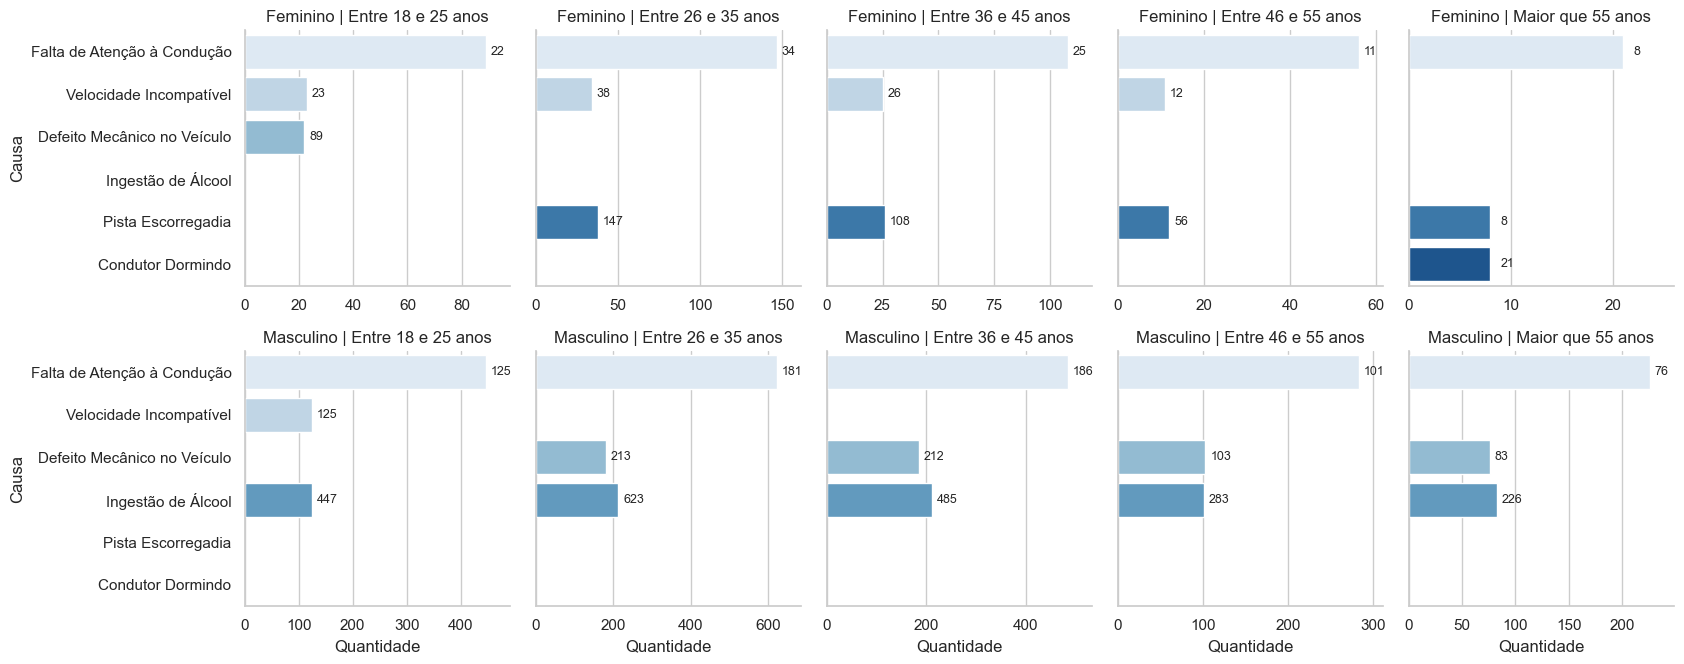

C:\Users\PR837UK\AppData\Local\Temp\ipykernel_11772\513469757.py:157: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sub, y="causa_acidente", x="qtd", palette=colors, ax=ax)
C:\Users\PR837UK\AppData\Local\Temp\ipykernel_11772\513469757.py:157: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sub, y="causa_acidente", x="qtd", palette=colors, ax=ax)


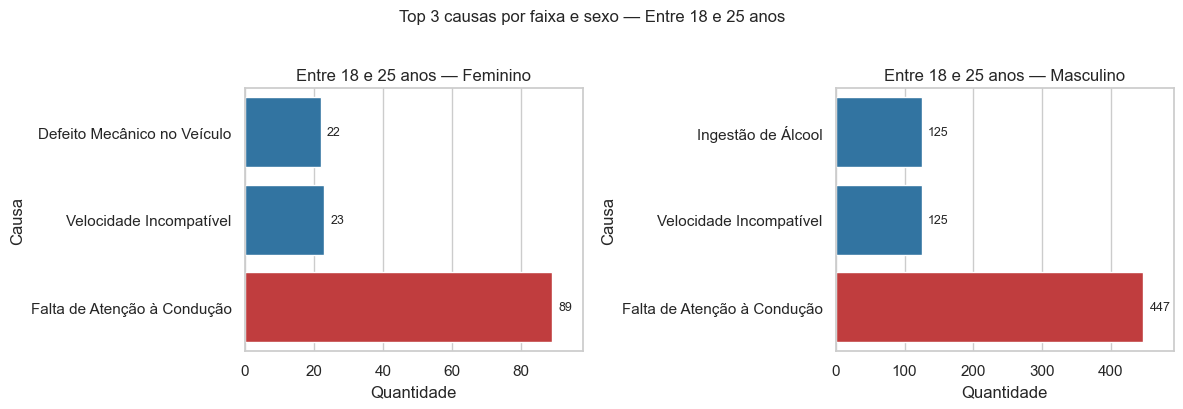

C:\Users\PR837UK\AppData\Local\Temp\ipykernel_11772\513469757.py:157: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sub, y="causa_acidente", x="qtd", palette=colors, ax=ax)
C:\Users\PR837UK\AppData\Local\Temp\ipykernel_11772\513469757.py:157: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sub, y="causa_acidente", x="qtd", palette=colors, ax=ax)


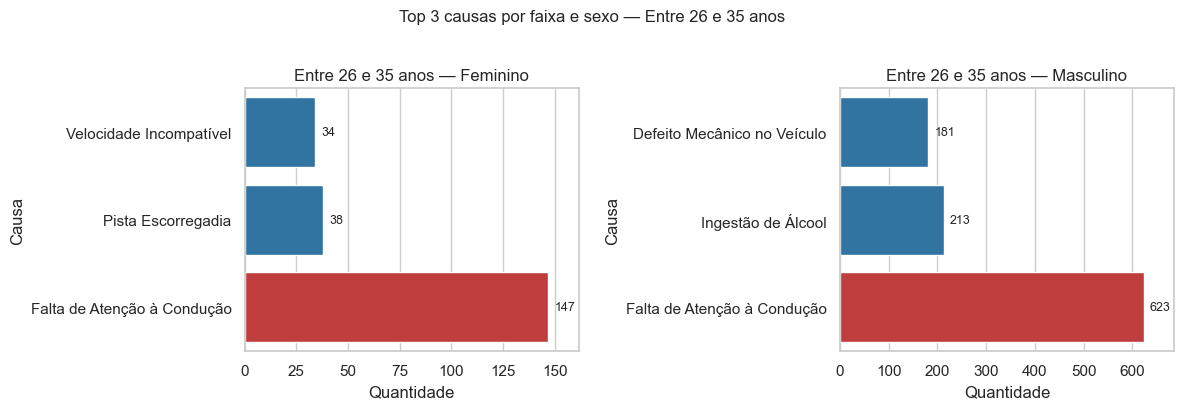

C:\Users\PR837UK\AppData\Local\Temp\ipykernel_11772\513469757.py:157: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sub, y="causa_acidente", x="qtd", palette=colors, ax=ax)
C:\Users\PR837UK\AppData\Local\Temp\ipykernel_11772\513469757.py:157: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sub, y="causa_acidente", x="qtd", palette=colors, ax=ax)


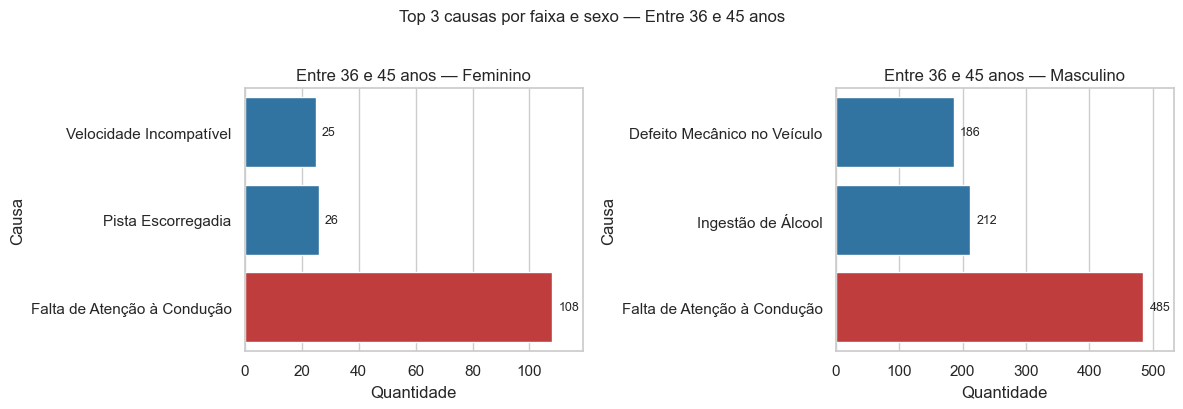

C:\Users\PR837UK\AppData\Local\Temp\ipykernel_11772\513469757.py:157: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sub, y="causa_acidente", x="qtd", palette=colors, ax=ax)
C:\Users\PR837UK\AppData\Local\Temp\ipykernel_11772\513469757.py:157: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sub, y="causa_acidente", x="qtd", palette=colors, ax=ax)


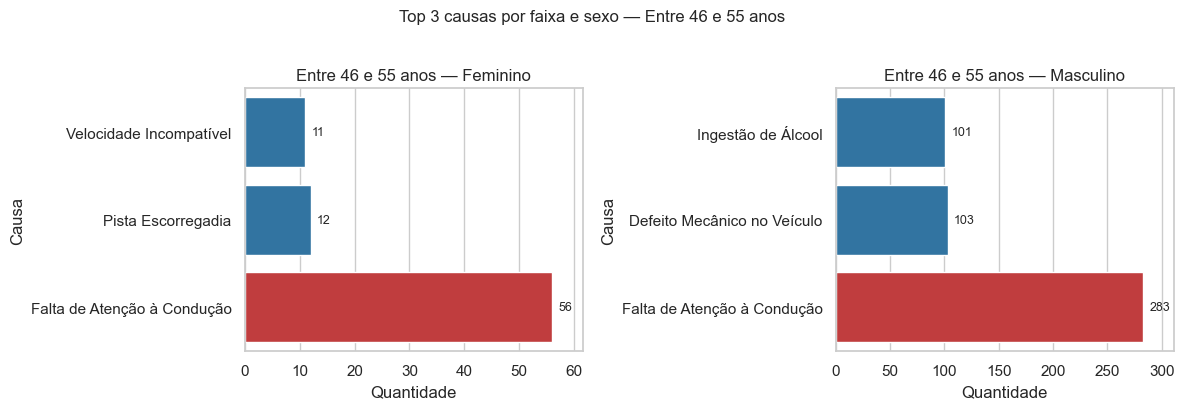

C:\Users\PR837UK\AppData\Local\Temp\ipykernel_11772\513469757.py:157: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sub, y="causa_acidente", x="qtd", palette=colors, ax=ax)
C:\Users\PR837UK\AppData\Local\Temp\ipykernel_11772\513469757.py:157: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sub, y="causa_acidente", x="qtd", palette=colors, ax=ax)


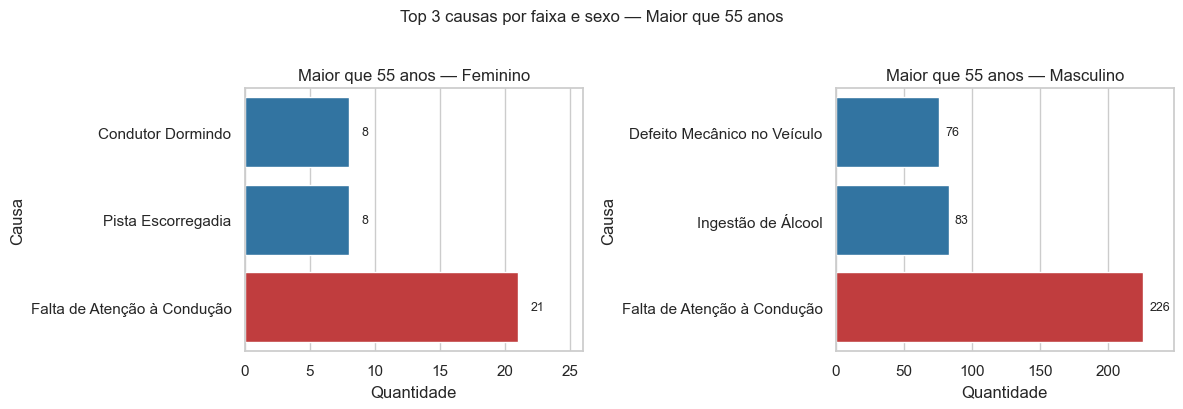

In [70]:
# %% [markdown]
# Principais causas de acidente por faixa etária e sexo (Top 3 por grupo)

# %%
# Copia do DataFrame original
df = df.copy()

# =========================
# 1) Limpeza/normalização mínima
# =========================
# Converte idade para numérico e mantém NaN onde for inválido
df["idade"] = pd.to_numeric(df["idade"], errors="coerce")

# Normaliza causa_acidente e sexo
df["causa_acidente"] = df["causa_acidente"].astype(str).str.strip()
df["sexo"] = df["sexo"].astype(str).str.strip()

# Remove registros sem idade/causa e fora de faixa plausível
df_valid = df[
    df["idade"].notna()
    & df["causa_acidente"].notna()
    & (df["causa_acidente"] != "")
].copy()
df_valid = df_valid[(df_valid["idade"] >= 18) & (df_valid["idade"] <= 120)]

# Remove sexo inválido (NaN já caiu), ignorando valores não informados
mascaras_excluir = df_valid["sexo"].str.lower().isin(["ignorado", "não informado", "nao informado", "na", "n/a", "null", "none", ""])
df_valid = df_valid[~mascaras_excluir].copy()

# =========================
# 2) Cria faixas etárias
# =========================
bins = [18, 25, 35, 45, 55, np.inf]
labels = [
    "Entre 18 e 25 anos",
    "Entre 26 e 35 anos",
    "Entre 36 e 45 anos",
    "Entre 46 e 55 anos",
    "Maior que 55 anos"
]

df_valid["faixa_idade"] = pd.cut(
    df_valid["idade"],
    bins=bins,
    labels=labels,
    right=True,         # inclui o limite superior na faixa (25 -> '18-25')
    include_lowest=True
)

# Garante a ordem das faixas
df_valid["faixa_idade"] = df_valid["faixa_idade"].astype(
    pd.CategoricalDtype(categories=labels, ordered=True)
)

# (Opcional) Padroniza sexo (ex.: primeira letra maiúscula)
df_valid["sexo"] = df_valid["sexo"].str.title()

# =========================
# 3) Contagem por faixa x sexo x causa
# =========================
contagem = (
    df_valid.groupby(["faixa_idade", "sexo", "causa_acidente"])
            .size()
            .reset_index(name="qtd")
)

# =========================
# 4) Top 3 por (faixa_idade, sexo) — exatamente 3
# =========================
# Ordena por qtd desc e desempata por causa alfabética
contagem_sorted = contagem.sort_values(
    by=["faixa_idade", "sexo", "qtd", "causa_acidente"],
    ascending=[True, True, False, True]
)

# Pega as 3 primeiras por grupo (quando houver)
top3_por_faixa_sexo = (
    contagem_sorted
    .groupby(["faixa_idade", "sexo"], as_index=False)
    .head(3)
    .reset_index(drop=True)
)

print("=== Top 3 causas por faixa de idade e sexo ===")
print(top3_por_faixa_sexo)

# %% [markdown]
# ## 5) Visualizações

# %%
sns.set_theme(style="whitegrid")

# ---------- (A) Facetas: linhas = sexo, colunas = faixa ----------
facet_df = top3_por_faixa_sexo.copy()

if not facet_df.empty:
    # Para leitura, ordena dentro de cada faceta
    facet_df = facet_df.sort_values(
        ["faixa_idade", "sexo", "qtd", "causa_acidente"],
        ascending=[True, True, False, True]
    )

    g = sns.catplot(
        data=facet_df,
        x="qtd",
        y="causa_acidente",
        col="faixa_idade",
        row="sexo",
        kind="bar",
        height=3.4,
        sharex=False,
        palette="Blues"
    )
    g.set_titles(row_template="{row_name}", col_template="{col_name}")
    g.set_axis_labels("Quantidade", "Causa")

    # Adiciona rótulos de valor em cada barra, por eixo
    axes = g.axes.flatten() if hasattr(g, "axes") else [g.ax]
    # Agrupa exatamente na mesma ordem que o catplot plota: por linha (sexo), depois coluna (faixa)
    grouped = list(facet_df.groupby(["sexo", "faixa_idade"]))
    for ax, ((sx, fx), sub) in zip(axes, grouped):
        sub_sorted = sub.sort_values("qtd", ascending=True)
        max_q = sub_sorted["qtd"].max()
        off = max(0.02 * max_q, 1)
        for p, v in zip(ax.patches, sub_sorted["qtd"].tolist()):
            x = p.get_width()
            y = p.get_y() + p.get_height() / 2
            ax.text(x + off, y, f"{int(v):,}".replace(",", "."), va="center", ha="left", fontsize=9)
        ax.set_xlim(0, max_q + 5 * off)

    plt.tight_layout()
    plt.show()

# ---------- (B) (Opcional) Um gráfico por faixa, com painéis por sexo ----------
# Cada faixa gera duas (ou mais) barras (Top 3) por sexo em subplots lado a lado
for faixa in labels:
    sub_faixa = top3_por_faixa_sexo[top3_por_faixa_sexo["faixa_idade"] == faixa]
    if sub_faixa.empty:
        continue

    sexos = sub_faixa["sexo"].unique().tolist()
    ncols = len(sexos)
    fig, axes = plt.subplots(1, ncols, figsize=(6*ncols, 4), sharey=False)
    if ncols == 1:
        axes = [axes]

    for ax, sx in zip(axes, sexos):
        sub = (
            sub_faixa[sub_faixa["sexo"] == sx]
            .sort_values("qtd", ascending=True)
        )
        # Cores: destaca a maior barra em vermelho
        colors = ["#1f77b4"] * len(sub)
        if len(colors) > 0:
            colors[-1] = "#d62728"

        sns.barplot(data=sub, y="causa_acidente", x="qtd", palette=colors, ax=ax)
        ax.set_title(f"{faixa} — {sx}")
        ax.set_xlabel("Quantidade")
        ax.set_ylabel("Causa")

        max_q = sub["qtd"].max()
        off = max(0.02 * max_q, 1)
        for p, v in zip(ax.patches, sub["qtd"].tolist()):
            x = p.get_width()
            y = p.get_y() + p.get_height() / 2
            ax.text(x + off, y, f"{int(v):,}".replace(",", "."), va="center", ha="left", fontsize=9)
        ax.set_xlim(0, max_q + 5 * off)

    fig.suptitle(f"Top 3 causas por faixa e sexo — {faixa}", y=1.02, fontsize=12)
    plt.tight_layout()
    plt.show()

**Quantidade de acidentes por faixa etária e sexo**

C:\Users\PR837UK\AppData\Local\Temp\ipykernel_11772\3781653284.py:44: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["faixa_idade", "sexo"])


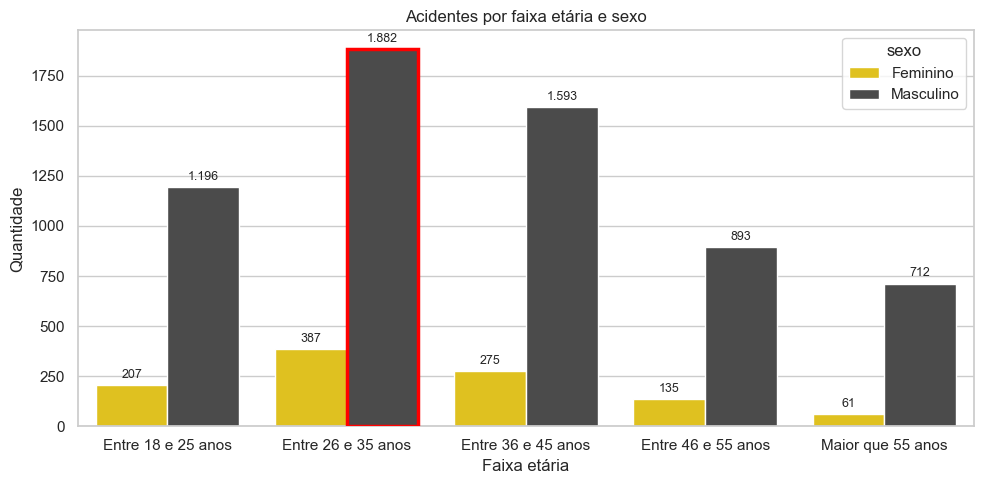


=== Informações do Gráfico ===
Total geral de registros: 7.341
Total por sexo:
  - Feminino: 1.065
  - Masculino: 6.276
Faixa etária com maior concentração: Entre 26 e 35 anos
Sexo com maior quantidade global: Masculino


C:\Users\PR837UK\AppData\Local\Temp\ipykernel_11772\3781653284.py:103: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  faixa_top = freq.groupby("faixa_idade")["qtd"].sum().idxmax()


In [71]:
# =========================
# 1) Leitura dos dados
# =========================
# Se estiver no Databricks, use:
# df = spark.table("nome_da_tabela").toPandas()
# Se for arquivo local:
# df = pd.read_csv("caminho_arquivo.csv")

# Aqui assumimos que a tabela já está carregada como df_casco:
# Lê todos os dados da tabela original

# =========================
# 2) Preparação dos dados
# =========================
df["idade"] = pd.to_numeric(df["idade"], errors="coerce")
df["sexo"] = df["sexo"].astype(str).str.strip()

# Remove valores inválidos de sexo
mask_sexo_inval = df["sexo"].str.lower().isin(
    ["ignorado", "não informado", "nao informado", "na", "n/a", "null", "none", ""]
)
df = df[~mask_sexo_inval & df["sexo"].notna()]

# Mantém idades plausíveis
df = df[(df["idade"].notna()) & (df["idade"] >= 18) & (df["idade"] <= 120)]

# Cria faixas etárias
bins = [18, 25, 35, 45, 55, np.inf]
labels = [
    "Entre 18 e 25 anos",
    "Entre 26 e 35 anos",
    "Entre 36 e 45 anos",
    "Entre 46 e 55 anos",
    "Maior que 55 anos"
]
df["faixa_idade"] = pd.cut(df["idade"], bins=bins, labels=labels, right=True, include_lowest=True)
df["faixa_idade"] = df["faixa_idade"].astype(pd.CategoricalDtype(categories=labels, ordered=True))
df["sexo"] = df["sexo"].str.title()

# =========================
# 3) Tabela de frequências
# =========================
freq = (
    df.groupby(["faixa_idade", "sexo"])
      .size()
      .reset_index(name="qtd")
)

# =========================
# 4) Gráfico de barras agrupadas
# =========================
sns.set_theme(style="whitegrid")

# Paleta fixa: Masculino cinza chumbo, Feminino dourado
palette = {"Masculino": "#4B4B4B", "Feminino": "#FFD700"}
for sx in freq["sexo"].unique():
    if sx not in palette:
        palette[sx] = "#888888"

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=freq,
    x="faixa_idade", y="qtd", hue="sexo",
    palette=palette
)

ax.set_title("Acidentes por faixa etária e sexo")
ax.set_xlabel("Faixa etária")
ax.set_ylabel("Quantidade")

# Rótulos nas barras
for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(f"{int(h):,}".replace(",", "."),
                    (p.get_x() + p.get_width()/2, h),
                    ha="center", va="bottom", fontsize=9, xytext=(0, 3), textcoords="offset points")

# =========================
# 5) Destacar a barra de maior valor com contorno vermelho
# =========================
heights = [p.get_height() for p in ax.patches]
if heights:
    max_idx = int(np.argmax(heights))
    max_patch = ax.patches[max_idx]
    rect = Rectangle(
        (max_patch.get_x(), 0),
        max_patch.get_width(),
        max_patch.get_height(),
        fill=False, edgecolor="red", linewidth=2.5
    )
    ax.add_patch(rect)
    rect.set_zorder(5)

plt.tight_layout()
plt.show()

# =========================
# 6) Informações descritivas
# =========================
total_geral = freq["qtd"].sum()
totais_por_sexo = freq.groupby("sexo")["qtd"].sum().to_dict()
faixa_top = freq.groupby("faixa_idade")["qtd"].sum().idxmax()
sexo_top = max(totais_por_sexo, key=totais_por_sexo.get)

print("\n=== Informações do Gráfico ===")
print(f"Total geral de registros: {total_geral:,}".replace(",", "."))
print("Total por sexo:")
for sexo, qtd in totais_por_sexo.items():
    print(f"  - {sexo}: {qtd:,}".replace(",", "."))
print(f"Faixa etária com maior concentração: {faixa_top}")
print(f"Sexo com maior quantidade global: {sexo_top}")